In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import copy
import time
from typing import Any, Dict, List, Optional, Tuple, Union
from pathlib import Path
import kagglehub

# Check hardware - if this shows 'cpu', the training will be slow but more stable
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Helper to ensure a directory exists
def _ensure_dir(p):
    Path(p).mkdir(parents=True, exist_ok=True)


c:\Users\Sky-fi\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
def plot_lr_schedule(
    lr_history: List[float],
    save_path: Optional[str] = None,
    title: str = "Learning Rate Decay vs. Epochs",
) -> None:
    """Plot the learning-rate schedule across training epochs."""
    if save_path is None:
        _ensure_dir(RESULTS_DIR)
        save_path = os.path.join(str(RESULTS_DIR), "lr_schedule.png")

    epochs = list(range(1, len(lr_history) + 1))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, lr_history, marker="o", linewidth=2, color="#1f77b4")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.set_title(title)
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"LR schedule plot saved → {save_path}")


def plot_training_curves(
    history: Dict[str, List[float]],
    model_name: str = "model",
    save_dir: Optional[Union[str, Path]] = None,
) -> None:
    """Plot train/val loss and accuracy curves side by side."""
    if save_dir is None:
        save_dir = RESULTS_DIR
    _ensure_dir(save_dir)

    epochs = list(range(1, len(history["train_loss"]) + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(epochs, history["train_loss"], label="Train Loss")
    ax1.plot(epochs, history["val_loss"], label="Val Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{model_name} — Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(epochs, history["train_acc"], label="Train Acc")
    ax2.plot(epochs, history["val_acc"], label="Val Acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title(f"{model_name} — Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    fname = Path(save_dir) / f"{model_name}_curves.png"
    fig.savefig(str(fname), dpi=150)
    plt.close(fig)
    print(f"Training curves saved → {fname}")


In [95]:
# Weight-initialisation helper
# Apply Kaiming (He) uniform initialisation to every Conv2d and Linear layer in model.
def _apply_kaiming_init(model: nn.Module) -> None:
    for m in model.modules():
        w = getattr(m, 'weight', None)
        b = getattr(m, 'bias', None)
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            if w is not None:
                init.kaiming_uniform_(w, nonlinearity="relu")
            if b is not None:
                init.zeros_(b)
        elif isinstance(m, nn.BatchNorm2d):
            if w is not None:
                init.ones_(w)
            if b is not None:
                init.zeros_(b)

#region CoBo Model
# YoLo copy -- Cats Only Bark Once
class coboCNN(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        
        
        self.cobo = nn.Sequential(
            # dont forget activations
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(16),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(32,64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(64,64,kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.AvgPool2d(kernel_size=2, stride=2, padding=0),
            nn.ReLU(),
            
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
        )
        
        # LeNet-5 Original classifier
        self.classifier = nn.Sequential(
            
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1_568, 512),
            nn.Sigmoid(),
            nn.Linear(512, 343),
            nn.Sigmoid(),
        )

        # Apply initialization
        self._apply_kaiming_init()
        
    def _apply_kaiming_init(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                w = getattr(m, 'weight', None)
                b = getattr(m, 'bias', None)
                if w is not None:
                    nn.init.kaiming_uniform_(w, nonlinearity='relu')
                if b is not None:
                    nn.init.constant_(b, 0)
            else:
                b = getattr(m, 'bias', None)
                if b is not None:
                    try:
                        nn.init.constant_(b, 0)
                    except Exception:
                        pass

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cobo(x)
        x = x.view(x.size(0), -1) # Flattens feature maps
        x = self.classifier(x)
        return x
#endregion

In [4]:
# Download the dataset locally
dataset_dir = Path(kagglehub.dataset_download("andrewmvd/dog-and-cat-detection"))
print(f"Dataset downloaded to: {dataset_dir.resolve()}")

# Preview top-level files/folders.
for item in sorted(dataset_dir.iterdir()):
    print(f"- {item.name}")

Dataset downloaded to: C:\Users\Sky-fi\.cache\kagglehub\datasets\andrewmvd\dog-and-cat-detection\versions\1
- annotations
- images


In [ ]:
# Try to import refactored utilities from repo; fallback to definitions below
try:
    import importlib
    dp = importlib.import_module('src.data_processing')
    resize_and_pad_image = dp.resize_and_pad_image
    transform_bbox = dp.transform_bbox
    process_record = dp.process_record
    split_train_val = dp.split_train_val
    visualize_sample = dp.visualize_sample
except Exception:
    from sklearn.model_selection import train_test_split
    from tqdm import tqdm
    import random
    import xml.etree.ElementTree as ET

    def _get_bilinear():
        try:
            return Image.Resampling.BILINEAR
        except Exception:
            return getattr(Image, 'BILINEAR', 2)

    def resize_and_pad_image(img: Image.Image, size=(112,112)):
        W,H = size; w,h = img.size
        scale = min(W/w, H/h)
        new_w = max(1, int(round(w*scale)))
        new_h = max(1, int(round(h*scale)))
        img_resized = img.resize((new_w, new_h), resample=_get_bilinear())
        pad_left = (W - new_w) // 2; pad_top = (H - new_h) // 2
        canvas = Image.new("RGB", (W, H), (0,0,0))
        canvas.paste(img_resized, (pad_left, pad_top))
        return canvas, scale, pad_left, pad_top

    def transform_bbox(bbox, scale, pad_left, pad_top):
        xmin, ymin, xmax, ymax = bbox
        return (
            max(0, int(round(xmin*scale + pad_left))),
            max(0, int(round(ymin*scale + pad_top))),
            max(0, int(round(xmax*scale + pad_left))),
            max(0, int(round(ymax*scale + pad_top)))
        )

    def process_record(image_path, bbox, out_path, size=(112,112)):
        img = Image.open(image_path).convert("RGB")
        orig_w, orig_h = img.size
        canvas, scale, pad_left, pad_top = resize_and_pad_image(img, size=size)
        xmin, ymin, xmax, ymax = transform_bbox(bbox, scale, pad_left, pad_top)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        canvas.save(out_path)
        return {
            "image_path": str(out_path),
            "orig_w": orig_w,
            "orig_h": orig_h,
            "scale": float(scale),
            "pad_left": int(pad_left),
            "pad_top": int(pad_top),
            "xmin": int(xmin),
            "ymin": int(ymin),
            "xmax": int(xmax),
            "ymax": int(ymax)
        }

    def split_train_val(df, stratify_col="label", val_frac=0.2, random_state=42):
        if stratify_col in df.columns:
            t, v = train_test_split(df, test_size=val_frac, stratify=df[stratify_col], random_state=random_state)
        else:
            t, v = train_test_split(df, test_size=val_frac, random_state=random_state)
        return t.reset_index(drop=True), v.reset_index(drop=True)

    def visualize_sample(img_path, bbox, ax=None, show=False):
        if ax is None:
            fig, ax = plt.subplots()
        img = plt.imread(img_path)
        ax.imshow(img)
        import matplotlib.patches as patches
        xmin, ymin, xmax, ymax = bbox
        rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        if show:
            plt.show()


In [6]:
dataset_dir = Path(kagglehub.dataset_download("andrewmvd/dog-and-cat-detection"))
print("Dataset dir:", dataset_dir.resolve())
for p in sorted(dataset_dir.iterdir()):
    print("-", p.name)


Dataset dir: C:\Users\Sky-fi\.cache\kagglehub\datasets\andrewmvd\dog-and-cat-detection\versions\1
- annotations
- images


In [7]:
for p in dataset_dir.rglob("*.csv"):
    df_check = pd.read_csv(p, nrows=0) # Only reads header
    print(f"File: {p.name} | Columns: {list(df_check.columns)}")

In [8]:
# Find all XML files
xml_files = list(dataset_dir.rglob("*.xml"))
print(f"Found {len(xml_files)} XML files.")

data = []

for xml_path in tqdm(xml_files, desc="Processing XMLs"):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception:
        continue

    fname_node = root.find('filename')
    file_name = fname_node.text if fname_node is not None and fname_node.text else Path(xml_path).stem

    for obj in root.findall('object'):
        name_node = obj.find('name')
        label = name_node.text if name_node is not None and name_node.text else 'unknown'
        bbox = obj.find('bndbox')
        if bbox is None:
            continue

        xmin_n = bbox.find('xmin')
        ymin_n = bbox.find('ymin')
        xmax_n = bbox.find('xmax')
        ymax_n = bbox.find('ymax')
        if None in (xmin_n, ymin_n, xmax_n, ymax_n):
            continue

        try:
            xmin = int(getattr(xmin_n, 'text', '0') or '0')
            ymin = int(getattr(ymin_n, 'text', '0') or '0')
            xmax = int(getattr(xmax_n, 'text', '0') or '0')
            ymax = int(getattr(ymax_n, 'text', '0') or '0')
        except Exception:
            continue

        data.append({
            'filename': file_name,
            'class': label,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax
        })

# 3. Create the DataFrame
df = pd.DataFrame(data)
print(f"\nLoaded annotations shape: {df.shape}")
print(df.head())


Found 3686 XML files.


Processing XMLs: 100%|██████████| 3686/3686 [00:50<00:00, 73.44it/s] 



Loaded annotations shape: (3687, 6)
            filename class  xmin  ymin  xmax  ymax
0     Cats_Test0.png   cat    83    29   197   142
1     Cats_Test1.png   dog   128    22   240   222
2    Cats_Test10.png   dog   157    56   264   116
3   Cats_Test100.png   cat   142   145   206   209
4  Cats_Test1000.png   cat    36    14   289   312


In [9]:
# Expected final columns: image, label, xmin, ymin, xmax, ymax
colmap = {}
if 'file_name' in df.columns and 'label' in df.columns: colmap['file_name'] = 'image'
if 'image' not in df.columns: colmap[df.columns[0]] = 'image'
if 'class' in df.columns: colmap['class'] = 'label'
if 'x1' in df.columns: colmap['x1'] = 'xmin'
if 'y1' in df.columns: colmap['y1'] = 'ymin'
if 'x2' in df.columns: colmap['x2'] = 'xmax'
if 'y2' in df.columns: colmap['y2'] = 'ymax'
df = df.rename(columns=colmap)
required = {'image','label','xmin','ymin','xmax','ymax'}
if not required.issubset(set(df.columns)):
    raise ValueError(f"Annotations missing required columns: {required - set(df.columns)}")
# make image paths absolute if necessary
df['image'] = df['image'].apply(lambda p: str((dataset_dir / p) if not Path(p).is_absolute() else Path(p)))

In [10]:
train_df, val_df = split_train_val(df, stratify_col='label', val_frac=0.2, random_state=42)
print("Train/Val sizes:", len(train_df), len(val_df))

Train/Val sizes: 2949 738


In [11]:
# check if we have any overlap between train and val sets
overlap = set(train_df['image']) & set(val_df['image'])
print(f"Number of overlapping images: {len(overlap)}")
# should be 0

Number of overlapping images: 0


In [ ]:
# Define output paths
out_dir = Path("data/processed")
train_out_dir = out_dir / "train"
val_out_dir = out_dir / "val"

# Ensure directories exist
train_out_dir.mkdir(parents=True, exist_ok=True)
val_out_dir.mkdir(parents=True, exist_ok=True)

train_rows = []
val_rows = []

def process_df_rows(df_in, dst_dir, rows_out):
    pbar = tqdm(df_in.iterrows(), total=len(df_in), desc=f"Processing {dst_dir.name}")
    
    for i, r in pbar:
        img_path = dataset_dir / "images" / Path(r['image']).name
        
        if not img_path.exists():
            continue
            
        fname = img_path.name
        dst = dst_dir / fname
        bbox = (float(r['xmin']), float(r['ymin']), float(r['xmax']), float(r['ymax']))
        
        meta = process_record(img_path, bbox, dst, size=(112, 112))
        
        meta['label'] = r['label']
        rows_out.append(meta)

# Run processing for both splits
process_df_rows(train_df, train_out_dir, train_rows)
process_df_rows(val_df, val_out_dir, val_rows)

# Create new DataFrames and save to CSV
train_processed_df = pd.DataFrame(train_rows)
val_processed_df = pd.DataFrame(val_rows)

train_processed_df.to_csv(out_dir / "train.csv", index=False)
val_processed_df.to_csv(out_dir / "val.csv", index=False)

print(f"Successfully saved {len(train_processed_df)} train and {len(val_processed_df)} val records.")
print(f"Processed data located at: {out_dir.resolve()}")

# Create a combined processed dataframe for visualization and quick checks
proc_df = pd.concat([train_processed_df, val_processed_df], ignore_index=True)
print(f"Combined processed dataframe rows: {len(proc_df)}")

# Minimal training helpers and imports to satisfy notebook flow
from torch.optim import Adam, SGD, RMSprop
from torch.optim.lr_scheduler import StepLR

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # changed names for my own clarity
    for image, label, bbox in loader:
        image = image.to(device)
        label = label.to(device)
        bbox = bbox.to(device)
        
        optimizer.zero_grad()
        outputs = model(image)
        loss = criterion(outputs, label, bbox)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * image.size(0)
        
        outputs_reshaped = outputs.reshape(-1, 7, 7, 7)
        pred_class = outputs_reshaped[..., :2]       
        preds = pred_class.sum(dim=(1,2)).argmax(dim=1)   

        correct += (preds == label).sum().item()
        total   += image.size(0)
        
    return (running_loss / total) if total > 0 else 0.0, (100.0 * correct / total) if total > 0 else 0.0


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb, bb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            bb = bb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb, bb)
            running_loss += loss.item() * xb.size(0)
                        
            outputs_reshaped = outputs.reshape(-1, 7, 7, 7)
            # This part needs to be adjusted, for now its grabbing the 'best class'
            pred_class = outputs_reshaped[..., :2] 
            preds = pred_class.sum(dim=(1,2)).argmax(dim=1)   
            correct += (preds == label).sum().item()
            total   += xb.size(0)
    return (running_loss / total) if total > 0 else 0.0, (100.0 * correct / total) if total > 0 else 0.0


Processing val: 100%|██████████| 738/738 [00:05<00:00, 144.52it/s]

Successfully saved 2949 train and 738 val records.
Processed data located at: C:\Users\Sky-fi\Documents\School\INFOMCV\UU_CV_Dog_Cat_object_detection\notebooks\data\processed
Combined processed dataframe rows: 3687


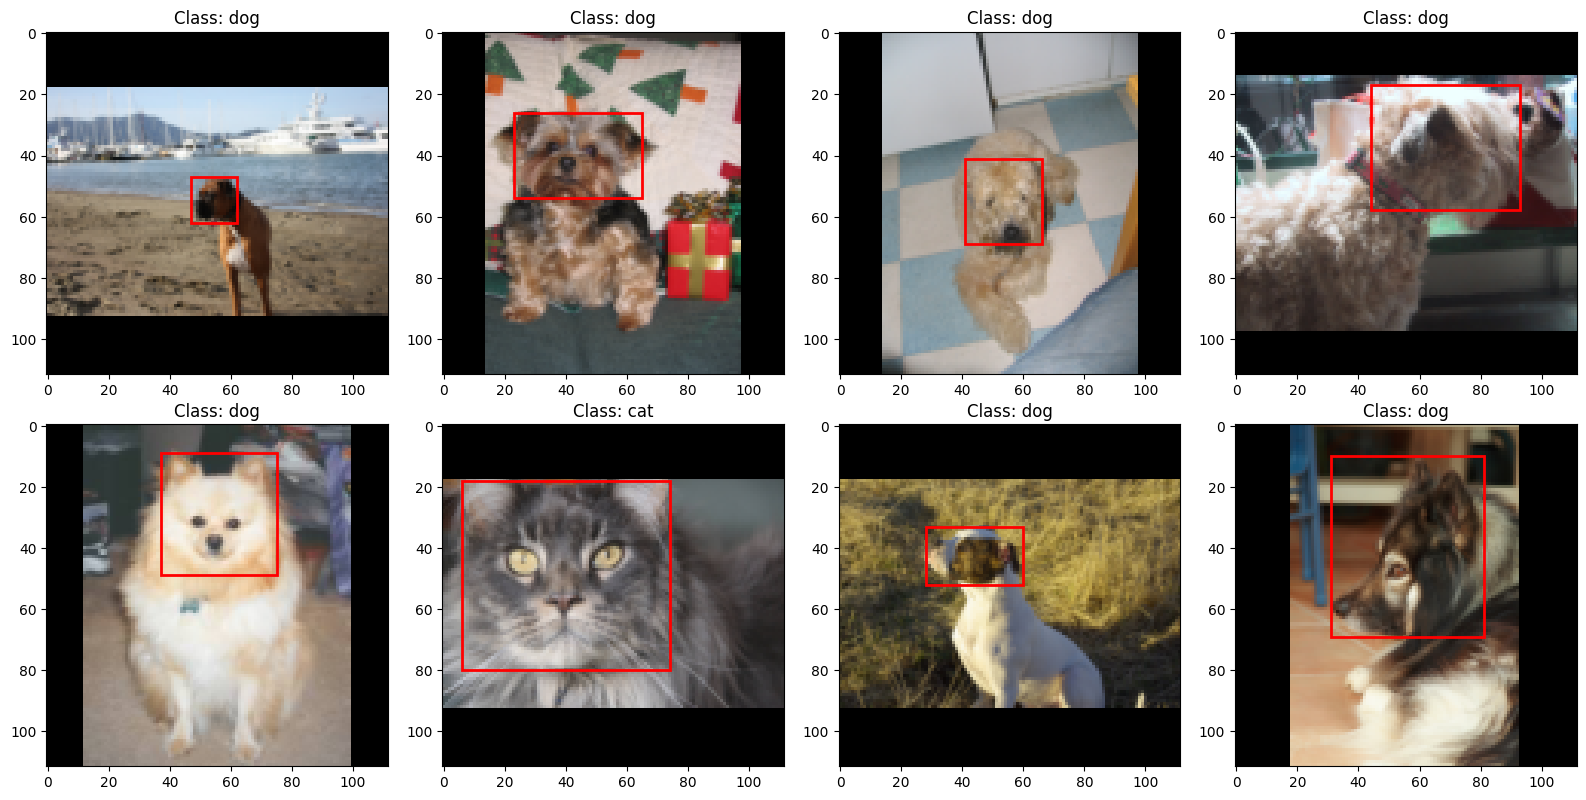

In [13]:
# Setup sample data
num_samples = min(8, len(proc_df))
indices = random.sample(range(len(proc_df)), num_samples)

# Create the figure and grid (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()  # Flatten to easily loop with a single index

for i, idx in enumerate(indices):
    row = proc_df.iloc[idx]
    img_p = Path(row['image_path'])
    bbox = (int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax']))
    visualize_sample(img_p, bbox, ax=axes[i])
    axes[i].set_title(f"Class: {row.get('label', 'N/A')}")

# Clean up layout
plt.tight_layout()
plt.show()

In [121]:
## Helper Function calculating the intersection over union
## => How much does predicted box overlap with target box
def intersection_over_union(box_target, box_pred):
    
    box2_x1 = box_target[..., 0:1] - box_target[..., 2:3] / 2
    box2_y1 = box_target[..., 1:2] - box_target[..., 3:4] / 2
    box2_x2 = box_target[..., 0:1] + box_target[..., 2:3] / 2
    box2_y2 = box_target[..., 1:2] + box_target[..., 3:4] / 2
    
    box1_x1 = box_pred[..., 0:1] - box_pred[..., 2:3] / 2
    box1_y1 = box_pred[..., 1:2] - box_pred[..., 3:4] / 2
    box1_x2 = box_pred[..., 0:1] + box_pred[..., 2:3] / 2
    box1_y2 = box_pred[..., 1:2] + box_pred[..., 3:4] / 2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)   

    box1_area = torch.abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = torch.abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    union = box1_area + box2_area - intersection + 1e-6      

    iou = intersection / union   

    return iou

# region Loss Function
### Loss Functions
## This assumes the tensor output of the model is [cat, dog, confidence, x,y,w,h]
## prediction would have [cat, dog, confidence, x,y,w,h]
# https://towardsdatascience.com/yolov1-loss-function-walkthrough-regression-for-all/

# NOTE: Gonna go through the code and clean it up

class coboLoss(nn.Module):
    
    lambda_coord = 5
    lambda_noobj = .5
    C = 2
    B = 1
    S = 7

    def __init__(self):
        super(coboLoss, self).__init__()
        
    # Bounding Box loss
    def boxLoss(self, box, target):
        img_s = 112
        
        # normalize box values between 0-1
        target_n = target.float() / img_s
        
        # step 2: get center coord from target box and w/h from target box
        target_x = (target_n[..., 0] + target_n[..., 1]) / 2
        target_y = (target_n[..., 2] + target_n[..., 3]) / 2
        target_w  =  target_n[..., 1] - target_n[..., 0]
        target_h  =  target_n[..., 3] - target_n[..., 2]
        target_box = torch.stack([target_x, target_y, target_w, target_h], dim=-1)
                
        cell_col = (target_x * self.S).long().clamp(0, self.S - 1)
        cell_row = (target_y * self.S).long().clamp(0, self.S - 1)

        target_grid = torch.zeros_like(box)
        for b in range(box.shape[0]):
            target_grid[b, cell_row[b], cell_col[b]] = target_box[b]

        # step 4: apply obj mask
        pred_masked   = self.obj.unsqueeze(-1) * box
        target_masked = self.obj.unsqueeze(-1) * target_grid

        # step 5: sqrt of w, h
        target_xy = target_masked[..., :2]
        target_wh = torch.sqrt(target_masked[..., 2:4].clamp(0))
        target_masked = torch.cat([target_xy, target_wh], dim=-1)

        pred_xy = pred_masked[..., :2]
        pred_wh = torch.sign(pred_masked[..., 2:4]) * \
                torch.sqrt(torch.abs(pred_masked[..., 2:4]) + 1e-6)
        pred_masked = torch.cat([pred_xy, pred_wh], dim=-1)
        box_loss = torch.sum((pred_masked - target_masked) ** 2)

        pred_iou = intersection_over_union(box, target_grid)

        return box_loss, pred_iou
    
    # Is there an object? (IoU)
    def objectLoss(self, conf, pred_iou):
        
        obj_loss = torch.sum(
            (self.obj.unsqueeze(-1) * conf - self.obj.unsqueeze(-1) * pred_iou) ** 2
        )

        no_obj_loss = torch.sum(
            (self.noobj.unsqueeze(-1) * conf) ** 2 
        )

        return obj_loss, no_obj_loss
    
    # classification correct?
    def classLoss(self, input, target):
        # one hot encode target: [batch, 2]
        target_onehot = torch.zeros(target.shape[0], self.C).to(target.device)
        target_onehot.scatter_(1, target.unsqueeze(1).long(), 1)

        # expand to grid [batch, 7, 7, 2]
        target_grid = target_onehot.unsqueeze(1).unsqueeze(1).expand(-1, self.S, self.S, -1)

        class_loss = torch.sum(
            (self.obj.unsqueeze(-1) * input - self.obj.unsqueeze(-1) * target_grid) ** 2
        )

        return class_loss
    
    def forward(self, input, target_label, target_box):
        batch = input.shape[0]
        # note: might have to look over and see if this is actually correct
        input = input.reshape(-1, 7, 7, 2 + 5) # size, size, x, y, w, h, confidence 

        pred_box = input[..., 2:6]
        pred_conf = input[..., 7:8]
        pred_class = input[..., :2]
        
        # obj/noobj masks 
        img_s = 112
        target_n = target_box.float() / img_s
        target_x = (target_n[:, 0] + target_n[:, 1]) / 2
        target_y = (target_n[:, 2] + target_n[:, 3]) / 2

        # double check if this is calculating the masks correctly
        cell_col = (target_x * self.S).long().clamp(0, self.S - 1)
        cell_row = (target_y * self.S).long().clamp(0, self.S - 1)

        self.obj   = torch.zeros(batch, self.S, self.S).to(input.device)
        self.noobj = torch.ones(batch,  self.S, self.S).to(input.device)

        for b in range(batch):
            self.obj[b,   cell_row[b], cell_col[b]] = 1
            self.noobj[b, cell_row[b], cell_col[b]] = 0
        
        box_loss, iou = self.boxLoss(pred_box, target_box)
        object_loss, no_object_loss = self.objectLoss(pred_conf, iou)
        classification_loss = self.classLoss(pred_class, target_label)
        
        total_loss = (self.lambda_coord * box_loss) + object_loss + (self.lambda_noobj * no_object_loss) + classification_loss
        return total_loss
# endregion



In [114]:
def train_model(
    model_class,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    best_hyperparams: Dict[str, Any],
    epochs: int = 20,
    early_stopping: bool = True,
    patience: int = 3,
    monitor: str = "val_loss",
) -> Tuple[nn.Module, Dict[str, List[float]]]:
    
    opt_name = best_hyperparams["optimizer"]
    lr = best_hyperparams["learning_rate"]
    wd = best_hyperparams["weight_decay"]
    bs = best_hyperparams["batch_size"]

    # History dictionary for plotting
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "lr": []
    }
    # Best-model tracking (metric-aware)
    monitor_lower_is_better = monitor == "val_loss"
    best_metric = float("inf") if monitor_lower_is_better else 0.0
    best_weights = None
    best_epoch = 0
    epochs_without_improvement = 0
    converged = False

    if early_stopping:
        print(
            f"Early stopping enabled: monitor={monitor}, "
            f"patience={patience}, max_epochs={epochs}"
        )


    # Update data loaders if batch size changed
    train_loader_new = train_loader
    val_loader_new = val_loader
    if bs != train_loader.batch_size:
        train_loader_new = DataLoader(
            train_loader.dataset, batch_size=bs, shuffle=True,
            num_workers=getattr(train_loader, "num_workers", 0), pin_memory=True
        )
        val_loader_new = DataLoader(
            val_loader.dataset, batch_size=bs, shuffle=False,
            num_workers=getattr(val_loader, "num_workers", 0), pin_memory=True
        )

    model = model_class()
    model.to(device)

    if opt_name.lower() == "adam":
        optimizer = Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif opt_name.lower() == "sgd":
        optimizer = SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)
    elif opt_name.lower() == "rmsprop":
        optimizer = RMSprop(model.parameters(), lr=lr, weight_decay=wd)
    else:
        raise ValueError(f"Unsupported optimizer: {opt_name}")

    criterion = coboLoss()
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(epochs):
        t0 = time.time()
        
        train_loss, train_acc = train_one_epoch(model, train_loader_new, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader_new, criterion, device)
        
        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # Track best model based on monitored metric
        current_metric = val_loss if monitor_lower_is_better else val_acc
        improved = (
            current_metric < best_metric
            if monitor_lower_is_better
            else current_metric > best_metric
        )

        if improved:
            best_metric = current_metric
            best_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Early stopping check
        if early_stopping and epochs_without_improvement >= patience:
            print(
                f"\nConverged: {monitor} has not improved for "
                f"{patience} epochs (best {monitor}="
                f"{best_metric:.4f} at epoch {best_epoch})"
            )
            converged = True
            break
        scheduler.step()
        
        elapsed = time.time() - t0
        print(f"Epoch {epoch + 1:>3d}/{epochs} | LR {current_lr:.6f} | "
                f"Train Loss {train_loss:.4f} Acc {train_acc:6.2f}% | "
                f"Val Loss {val_loss:.4f} Acc {val_acc:6.2f}% | {elapsed:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
    
    # Summary
    if early_stopping and not converged:
        print(
            f"\nReached max epochs ({epochs}) without convergence. "
            f"Best {monitor}={best_metric:.4f} at epoch {best_epoch}."
        )

    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"Restored best model with validation accuracy: {best_val_acc:.2f}%")
        
    return model, history

In [34]:
# Train final model with best hyperparameters from search
def train_final_model(
    model_class,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    best_hyperparams: Dict[str, Any],
    epochs: int = 20,
) -> nn.Module:
    """
    Train the final model using the best hyperparameters found in the search.
    """
    opt_name = best_hyperparams["optimizer"]
    lr = best_hyperparams["learning_rate"]
    wd = best_hyperparams["weight_decay"]
    bs = best_hyperparams["batch_size"]

    print(f"Training final model with hyperparameters:")
    print(f"Optimizer: {opt_name}, LR: {lr}, Weight Decay: {wd}, Batch Size: {bs}")

    # Update data loaders if batch size changed
    if bs != train_loader.batch_size:
        train_loader_new = DataLoader(
            train_loader.dataset,
            batch_size=bs,
            shuffle=True,
            num_workers=getattr(train_loader, "num_workers", 0),
            pin_memory=True,
        )
        val_loader_new = DataLoader(
            val_loader.dataset,
            batch_size=bs,
            shuffle=False,
            num_workers=getattr(val_loader, "num_workers", 0),
            pin_memory=True,
        )
    else:
        train_loader_new = train_loader
        val_loader_new = val_loader

    # Create model
    model = model_class()
    model.to(device)

    # Setup optimizer
    if opt_name.lower() == "adam":
        optimizer = Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif opt_name.lower() == "sgd":
        optimizer = SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)
    elif opt_name.lower() == "rmsprop":
        optimizer = RMSprop(model.parameters(), lr=lr, weight_decay=wd)
    else:
        raise ValueError(f"Unsupported optimizer: {opt_name}")

    # Setup loss and scheduler
    criterion = coboLoss()
    scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader_new, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader_new, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch + 1:>3d}/{epochs} | "
            f"LR {current_lr:.6f} | "
            f"Train Loss {train_loss:.4f}  Acc {train_acc:6.2f}% | "
            f"Val Loss {val_loss:.4f}  Acc {val_acc:6.2f}% | "
            f"{elapsed:.1f}s"
        )
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"Restored best model with validation accuracy: {best_val_acc:.2f}%")
    return model

In [68]:
class CatDogDataset(Dataset):
    def __init__(self, image_paths, labels, bbox, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.bbox = bbox
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            # Load image only when requested
            img_path = self.image_paths[idx]
            image = Image.open(img_path).convert("RGB")
            label = self.labels[idx]
            bbox = self.bbox[idx]
            bbox = torch.tensor(self.bbox[idx], dtype=torch.float32)
            if self.transform:
                image = self.transform(image)
            return image, label, bbox
        except Exception as e:
            # If an image is corrupt, return a blank tensor instead of crashing
            return torch.zeros((3, 112, 112)), self.labels[idx]

# Define basic transforms
transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:

# Build train/val file lists and numeric labels from processed data
combined = pd.concat([train_processed_df, val_processed_df], ignore_index=True)
labels = sorted(combined['label'].unique())
label_map = {lab: i for i, lab in enumerate(labels)}

train_files = train_processed_df['image_path'].tolist()
train_labels = train_processed_df['label'].map(label_map).tolist()
train_bbox = [[a, b, c, d] for a, b, c, d in zip(train_processed_df['xmin'], 
                                                train_processed_df['xmax'], 
                                                train_processed_df['ymin'], 
                                                train_processed_df['ymax'])]

val_files = val_processed_df['image_path'].tolist()
val_labels = val_processed_df['label'].map(label_map).tolist()
val_bbox = [[a, b, c, d] for a, b, c, d in zip(val_processed_df['xmin'], 
                                            val_processed_df['xmax'], 
                                            val_processed_df['ymin'], 
                                            val_processed_df['ymax'])]



# Create datasets
train_dataset = CatDogDataset(train_files, train_labels, train_bbox, transform=transform)
val_dataset = CatDogDataset(val_files, val_labels, val_bbox, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [123]:
# Define hyperparameters
best_hps = {
    "optimizer": "adam",
    "learning_rate": 0.001,
    "weight_decay": 1e-4,
    "batch_size": 32 #recommended 8 for this assignment
}

# Train the model and get history
final_model, history = train_model(
    coboCNN, # Use your original model class name
    train_loader, 
    val_loader, 
    device, 
    best_hps, 
    epochs=20
)

# Plot the results
plot_training_curves(history, model_name="coboCNN_Final")
plot_lr_schedule(history["lr"])

# Save the model weights
torch.save(final_model.state_dict(), os.path.join(RESULTS_DIR, "final_model_weights.pth"))

Early stopping enabled: monitor=val_loss, patience=3, max_epochs=20
Epoch   1/20 | LR 0.001000 | Train Loss 21.5331 Acc  66.60% | Val Loss 18.8411 Acc 100.00% | 77.7s
Epoch   2/20 | LR 0.001000 | Train Loss 17.4859 Acc  67.38% | Val Loss 18.2767 Acc  76.15% | 7.1s
Epoch   3/20 | LR 0.001000 | Train Loss 15.8255 Acc  66.84% | Val Loss 18.3778 Acc  93.36% | 7.5s
Epoch   4/20 | LR 0.001000 | Train Loss 14.2368 Acc  69.07% | Val Loss 17.5882 Acc  73.85% | 7.8s
Epoch   5/20 | LR 0.001000 | Train Loss 12.7898 Acc  69.92% | Val Loss 17.5336 Acc  59.76% | 8.3s
Epoch   6/20 | LR 0.000500 | Train Loss 10.0598 Acc  72.97% | Val Loss 17.0110 Acc  72.76% | 15.0s
Epoch   7/20 | LR 0.000500 | Train Loss 8.4436 Acc  75.35% | Val Loss 17.1539 Acc  64.23% | 20.2s
Epoch   8/20 | LR 0.000500 | Train Loss 7.3543 Acc  75.18% | Val Loss 16.9200 Acc  49.05% | 19.6s
Epoch   9/20 | LR 0.000500 | Train Loss 6.3336 Acc  77.04% | Val Loss 16.8507 Acc  61.11% | 19.2s
Epoch  10/20 | LR 0.000500 | Train Loss 5.5428 A

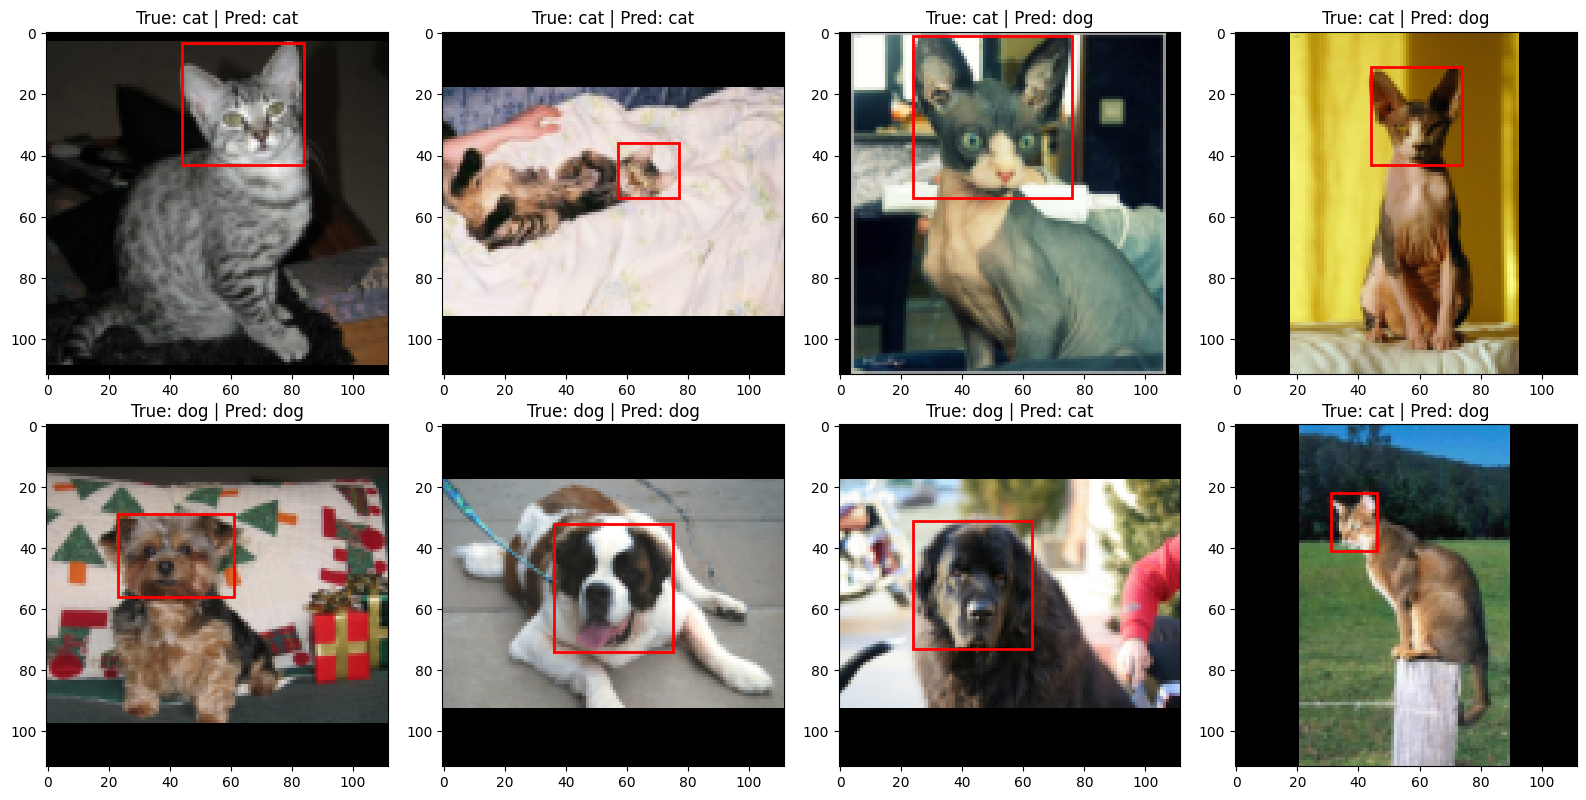

In [129]:
# test output model on a few samples with the bounding boxes visualized and the index of the predicted class shown under the bounding box. You can use the visualize_sample function defined earlier to draw the bounding boxes on the images, and then display the predicted class index as text on the plot. Here's how you can do it:
num_samples = min(8, len(val_dataset))
indices = random.sample(range(len(val_dataset)), num_samples)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, idx in enumerate(indices):
    img_path = val_files[idx]
    label = val_labels[idx]
    # Load and preprocess the image
    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)
    # Get model prediction
    with torch.no_grad():
        output = final_model(input_tensor)
        output_reshaped = output.reshape(1, 7, 7, 7)
        pred_class = output_reshaped[..., :2] 
        preds = pred_class.sum(dim=(1,2)).argmax(dim=1)   
    bbox = (
        int(val_processed_df.iloc[idx]['xmin']),
        int(val_processed_df.iloc[idx]['ymin']),
        int(val_processed_df.iloc[idx]['xmax']),
        int(val_processed_df.iloc[idx]['ymax'])
    )
    visualize_sample(img_path, bbox, ax=axes[i])
    axes[i].set_title(f"True: {labels[label]} | Pred: {labels[preds]}")

plt.tight_layout()
plt.show()